In [21]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
print("Libraries imported ✓")


Libraries imported ✓


In [23]:
file_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/lending_club_accepted_loans.csv'

In [24]:
dtype_dict = {
    'loan_amnt': 'float32',
    'funded_amnt': 'float32',
    'int_rate': 'float32',
    'annual_inc': 'float32',
    'dti': 'float32',
    'fico_range_low': 'float32',
    'fico_range_high': 'float32',
    'delinq_2yrs': 'int8',
    'inq_last_6mths': 'int8',
    'open_acc': 'int8',
    'pub_rec': 'int8',
    'revol_util': 'float32',
    'total_pymnt': 'float32',
    'loan_status': 'category',
    'grade': 'category',
    'sub_grade': 'category',
    'home_ownership': 'category',
    'verification_status': 'category',
    'purpose': 'category',
    'addr_state': 'category',
    'issue_d': 'string',          # we will turn this into date later
    'earliest_cr_line': 'string'
}


In [25]:
usecols = list(dtype_dict.keys())

print("Ready to load data...")


Ready to load data...


In [26]:
dtype_dict_for_loading = dtype_dict.copy()
for col in ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec']:
    dtype_dict_for_loading[col] = 'float32'

df_sample = pd.read_csv(
    file_path,
    usecols=usecols,
    dtype=dtype_dict_for_loading,
    low_memory=False,
    skiprows=lambda i: i>0 and np.random.rand() > 0.05
)
print('Sample dataset completed')

Sample dataset completed


In [27]:
df_sample.head()

,loan_amnt,funded_amnt,int_rate,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,loan_status,...,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_util,total_pymnt
0,3600.0,3600.0,13.990000,C,C4,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,...,5.910000,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,29.700001,4421.724121
1,1500.0,1500.0,6.490000,A,A2,MORTGAGE,45000.0,Not Verified,Dec-2015,Fully Paid,...,16.110001,0.0,Dec-1987,745.0,749.0,0.0,12.0,0.0,21.200001,1598.983398
2,23975.0,23975.0,19.889999,E,E3,RENT,70000.0,Not Verified,Dec-2015,Charged Off,...,33.200001,0.0,Jun-1995,685.0,689.0,1.0,10.0,0.0,94.900002,3928.860107
3,18500.0,18500.0,12.880000,C,C2,MORTGAGE,70000.0,Source Verified,Dec-2015,Fully Paid,...,13.200000,0.0,Jun-2002,675.0,679.0,1.0,9.0,0.0,57.799999,21912.003906
4,4000.0,4000.0,9.170000,B,B2,RENT,44500.0,Verified,Dec-2015,Fully Paid,...,15.830000,0.0,Sep-2003,670.0,674.0,0.0,4.0,1.0,4.200000,4399.022949


In [28]:
print(df_sample.shape)

(113103, 22)


In [29]:
missing = df_sample.isnull().sum().sort_values(ascending=False)
print('Top missing columns:\n',missing.head(15))

Top missing columns:
 dti                 86
revol_util          72
delinq_2yrs          1
earliest_cr_line     1
open_acc             1
inq_last_6mths       1
pub_rec              1
sub_grade            0
home_ownership       0
int_rate             0
funded_amnt          0
loan_amnt            0
grade                0
annual_inc           0
purpose              0
dtype: int64


In [30]:
credit_cols = ['delinq_2yrs', 'earliest_cr_line', 'open_acc', 'inq_last_6mths', 'pub_rec']
df_sample = df_sample.dropna(subset=credit_cols)

In [31]:
df_sample['revol_util'] = df_sample['revol_util'].fillna(df_sample['revol_util'].median())

In [32]:
df_sample['dti'] = df_sample['dti'].fillna(df_sample['dti'].median())

In [33]:
print(df_sample.info())

<class 'pandas.core.frame.DataFrame'>
Index: 113102 entries, 0 to 113102
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   loan_amnt            113102 non-null  float32 
 1   funded_amnt          113102 non-null  float32 
 2   int_rate             113102 non-null  float32 
 3   grade                113102 non-null  category
 4   sub_grade            113102 non-null  category
 5   home_ownership       113102 non-null  category
 6   annual_inc           113102 non-null  float32 
 7   verification_status  113102 non-null  category
 8   issue_d              113102 non-null  string  
 9   loan_status          113102 non-null  category
 10  purpose              113102 non-null  category
 11  addr_state           113102 non-null  category
 12  dti                  113102 non-null  float32 
 13  delinq_2yrs          113102 non-null  float32 
 14  earliest_cr_line     113102 non-null  string  
 15  fico_

In [34]:
print(df_sample[['dti', 'revol_util','delinq_2yrs', 'earliest_cr_line', 'open_acc', 'inq_last_6mths', 'pub_rec']].isnull().sum())

dti                 0
revol_util          0
delinq_2yrs         0
earliest_cr_line    0
open_acc            0
inq_last_6mths      0
pub_rec             0
dtype: int64


In [35]:
df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'], format='%b-%Y')
df_sample['year'] = df_sample['issue_d'].dt.year
df_sample['year'].value_counts().sort_index()

,count
year,
2007,27
2008,115
2009,244
2010,601
2011,1137
2012,2658
2013,6801
2014,11801
2015,20895


In [36]:
df_sample['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
Fully Paid,0.473519
Current,0.389525
Charged Off,0.120909
Late (31-120 days),0.009478
In Grace Period,0.003369
Late (16-30 days),0.002122
Does not meet the credit policy. Status:Fully Paid,0.000822
Does not meet the credit policy. Status:Charged Off,0.000230
Default,0.000027


In [37]:
df_sample.describe()

,loan_amnt,funded_amnt,int_rate,annual_inc,issue_d,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_util,total_pymnt,year
count,113102.000000,113102.000000,113102.000000,1.131020e+05,113102,113102.000000,113102.000000,113102.000000,113102.000000,113102.000000,113102.000000,113102.000000,113102.000000,113102.000000,113102.000000
mean,15055.277344,15049.151367,13.126692,7.805688e+04,2016-05-04 20:57:00.289650176,18.840048,0.309261,698.382141,702.382263,0.573359,11.617540,0.198767,50.376839,12044.626953,2015.863504
min,600.000000,600.000000,5.310000,0.000000e+00,2007-07-01 00:00:00,0.000000,0.000000,625.000000,629.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000
25%,8000.000000,8000.000000,9.580000,4.644150e+04,2015-04-01 00:00:00,11.870000,0.000000,675.000000,679.000000,0.000000,8.000000,0.000000,31.500000,4525.140015,2015.000000
50%,12975.000000,12950.000000,12.690000,6.500000e+04,2016-07-01 00:00:00,17.760000,0.000000,690.000000,694.000000,0.000000,11.000000,0.000000,50.400002,9322.781738,2016.000000
75%,20000.000000,20000.000000,15.990000,9.300000e+04,2017-11-01 00:00:00,24.450001,0.000000,715.000000,719.000000,1.000000,14.000000,0.000000,69.300003,16866.331055,2017.000000
max,40000.000000,40000.000000,30.990000,8.500021e+06,2018-12-01 00:00:00,999.000000,21.000000,845.000000,850.000000,27.000000,97.000000,26.000000,155.300003,62493.746094,2018.000000
std,9183.185547,9182.042969,4.846067,8.041496e+04,NaN,15.419797,0.862711,32.840229,32.837288,0.880721,5.666084,0.558989,24.728649,9877.708984,1.792458


In [38]:
df_sample.shape

(113102, 23)

In [39]:
drive_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/accepted_cleaned_sample.csv'
df_sample.to_csv(drive_path, index=False)
print(f"Saved to Google Drive: {drive_path}")

Saved to Google Drive: /content/drive/MyDrive/CIS450_LendingClub_Project/accepted_cleaned_sample.csv


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

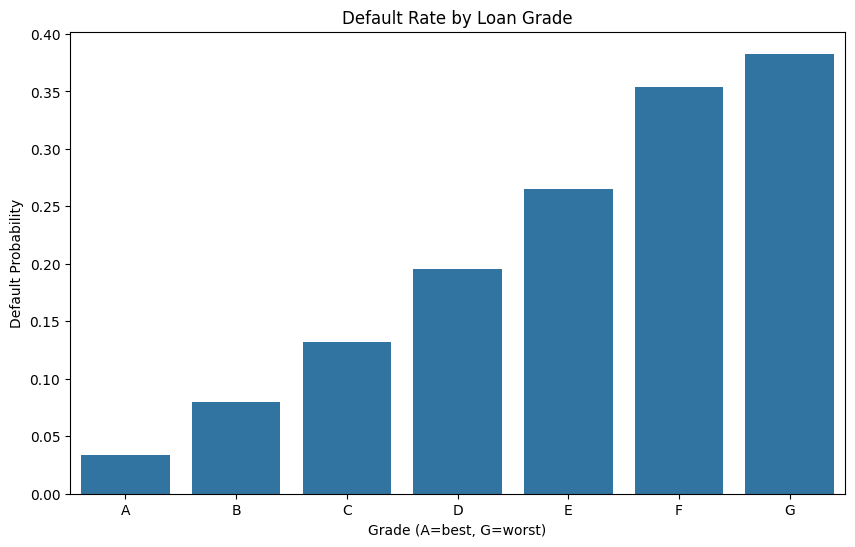

In [41]:
df_sample['is_default'] = df_sample['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)
plt.figure(figsize=(10,6))
sns.barplot(x='grade', y='is_default', data=df_sample, errorbar=None, order=sorted(df_sample['grade'].unique()))
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Probability')
plt.xlabel('Grade (A=best, G=worst)')
plt.show()

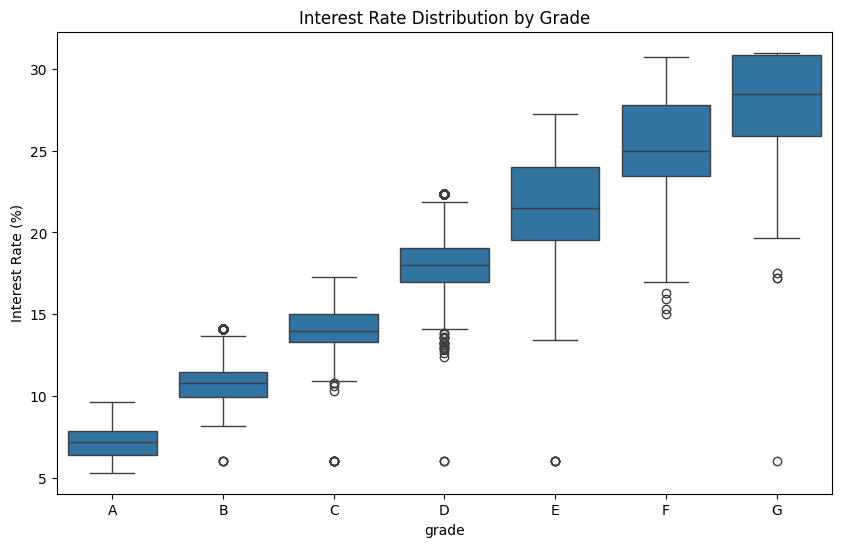

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grade', y='int_rate', data=df_sample, order=sorted(df_sample['grade'].unique()))
plt.title('Interest Rate Distribution by Grade')
plt.ylabel('Interest Rate (%)')
plt.show()

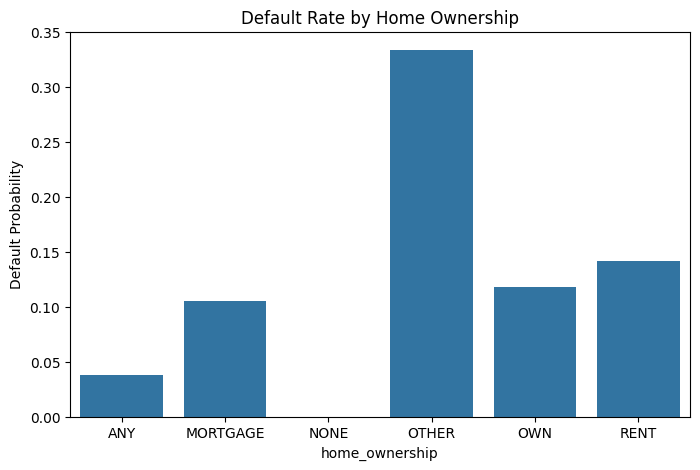

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(x='home_ownership', y='is_default', data=df_sample, errorbar=None)
plt.title('Default Rate by Home Ownership')
plt.ylabel('Default Probability')
plt.show()

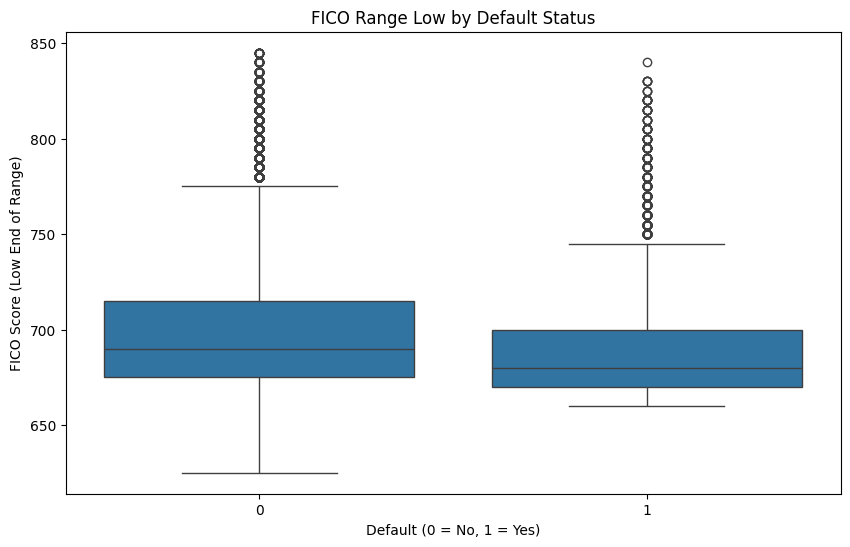

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_default', y='fico_range_low', data=df_sample)
plt.title('FICO Range Low by Default Status')
plt.ylabel('FICO Score (Low End of Range)')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.show()

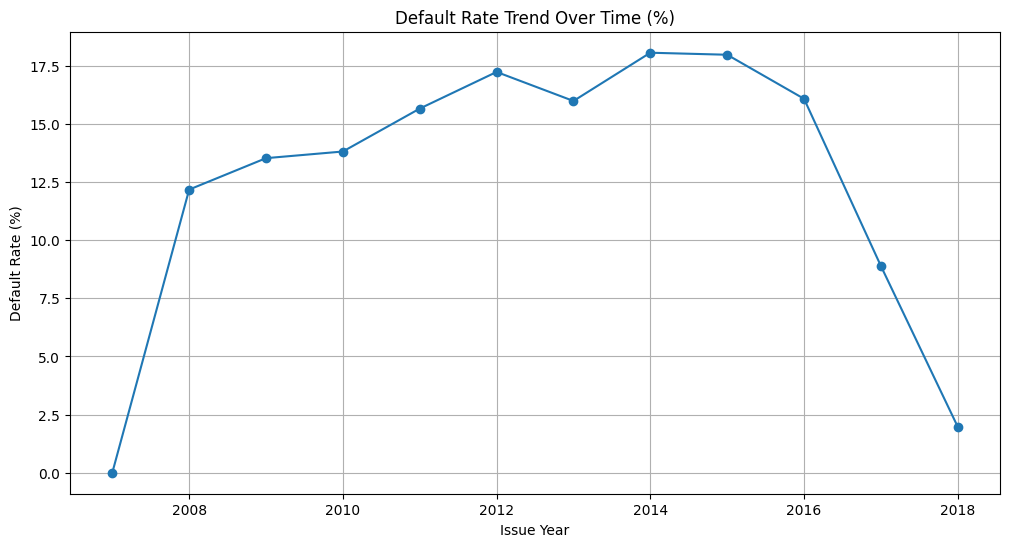

In [45]:
yearly_default = df_sample.groupby('year')['is_default'].mean() * 100

plt.figure(figsize=(12,6))
yearly_default.plot(kind='line', marker='o')
plt.title('Default Rate Trend Over Time (%)')
plt.ylabel('Default Rate (%)')
plt.xlabel('Issue Year')
plt.grid(True)
plt.show()

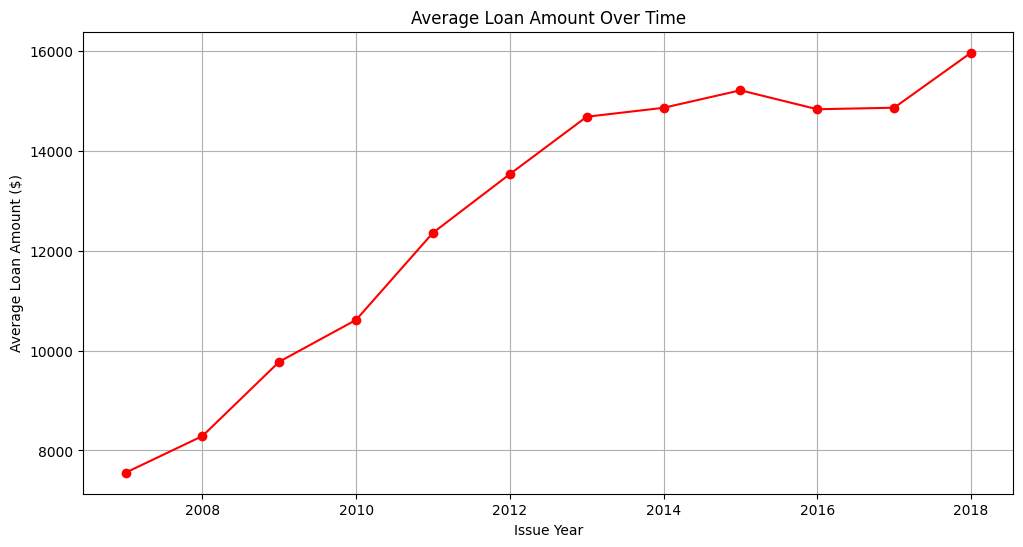

In [46]:
plt.figure(figsize=(12,6))
df_sample.groupby('year')['loan_amnt'].mean().plot(kind='line', marker='o', color='red')
plt.title('Average Loan Amount Over Time')
plt.ylabel('Average Loan Amount ($)')
plt.xlabel('Issue Year')
plt.grid(True)
plt.show()

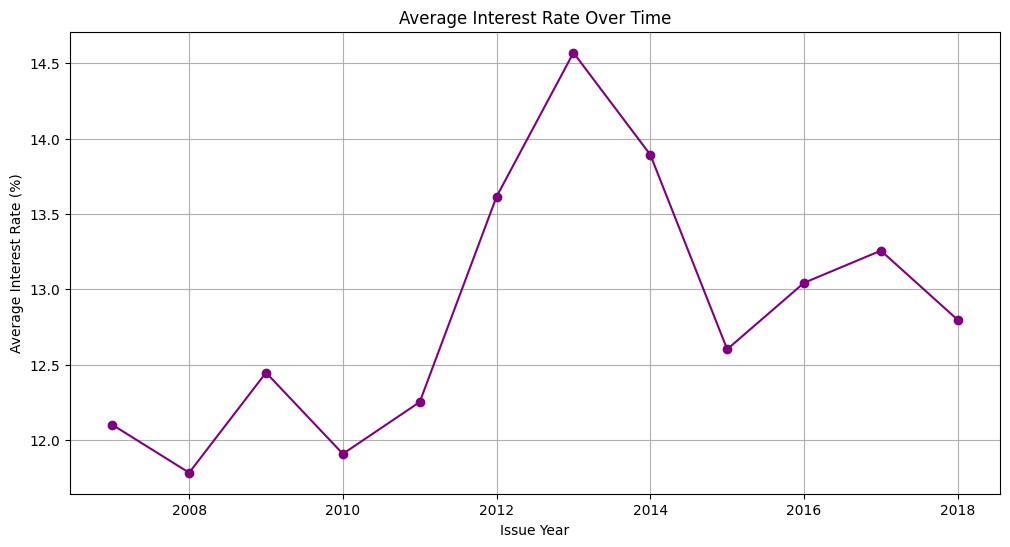

In [47]:
plt.figure(figsize=(12,6))
df_sample.groupby('year')['int_rate'].mean().plot(kind='line', marker='o', color='purple')
plt.title('Average Interest Rate Over Time')
plt.ylabel('Average Interest Rate (%)')
plt.xlabel('Issue Year')
plt.grid(True)
plt.show()

/tmp/ipykernel_2279/2702107568.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sample.groupby('purpose')['is_default'].mean().sort_values().plot(kind='barh', color='orange')


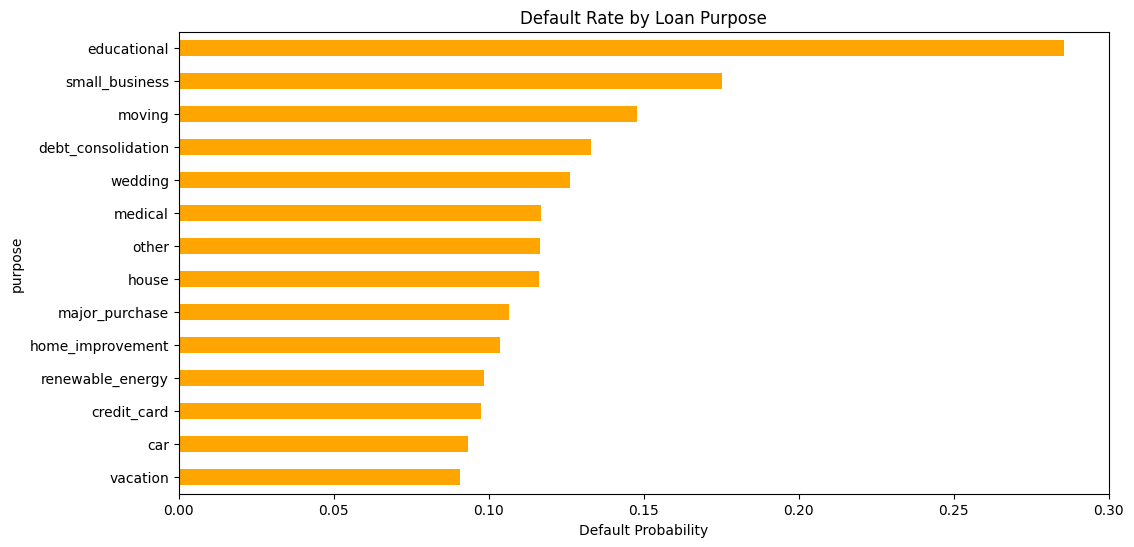

In [48]:
plt.figure(figsize=(12,6))
df_sample.groupby('purpose')['is_default'].mean().sort_values().plot(kind='barh', color='orange')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Probability')
plt.show()

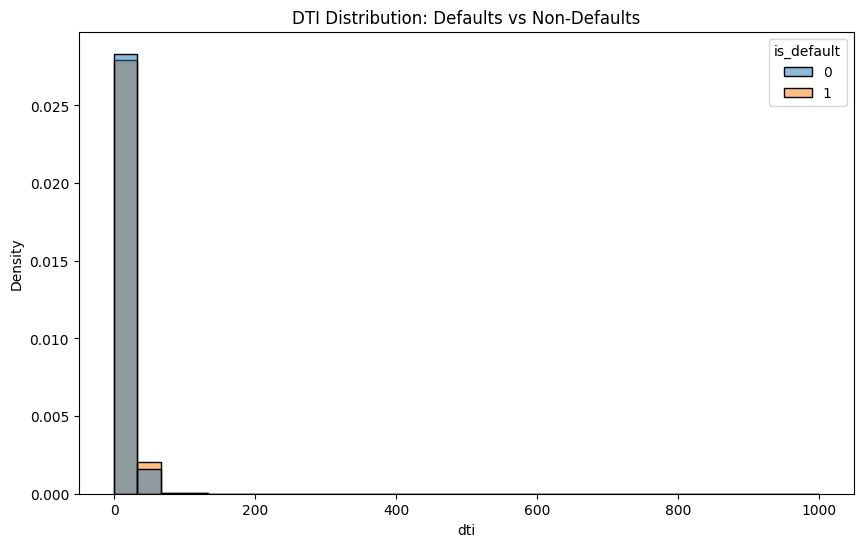

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_sample, x='dti', hue='is_default', bins=30, stat='density', common_norm=False)
plt.title('DTI Distribution: Defaults vs Non-Defaults')
plt.show()

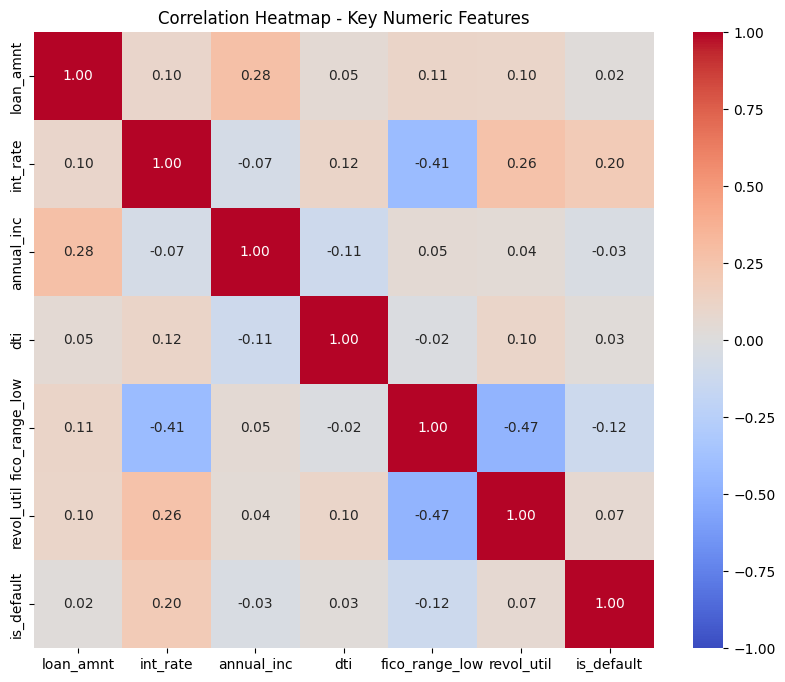

In [50]:
numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'is_default']
corr_matrix = df_sample[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap - Key Numeric Features')
plt.show()